In [ ]:
import pandas as pd
import numpy as np

# Visualization

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import matplotlib.dates as mdates

# Modeling

from sklearn.ensemble import RandomForestRegressor

# Metrics

from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

In [ ]:
ffill_df = pd.read_excel('/content/drive/MyDrive/COD_ML_Project/Data/(FINAL) for modeling/ffill_df_for_modeling.xlsx',
                         parse_dates = True).set_index('Datetime')

bfill_df = pd.read_excel('/content/drive/MyDrive/COD_ML_Project/Data/(FINAL) for modeling/bfill_df_for_modeling.xlsx',
                         parse_dates = True).set_index('Datetime')

interpolation_df = pd.read_excel('/content/drive/MyDrive/COD_ML_Project/Data/(FINAL) for modeling/interpolation_df_for_modeling.xlsx',
                         parse_dates = True).set_index('Datetime')



target_feature = 'IN, COD'

for_validation = 160
for_test = 160

# Setting target feature

ffill_train_target = ffill_df[target_feature].iloc[:-for_validation-for_test]
ffill_train_inputs = ffill_df.drop(columns=target_feature).iloc[:-for_validation-for_test]

ffill_val_target = ffill_df[target_feature].iloc[-for_validation-for_test:-for_test]
ffill_val_inputs = ffill_df.drop(columns=target_feature).iloc[-for_validation-for_test:-for_test]

ffill_test_target = ffill_df[target_feature].iloc[-for_test:]
ffill_test_inputs = ffill_df.drop(columns=target_feature).iloc[-for_test:]


bfill_train_target = bfill_df[target_feature].iloc[:-for_validation-for_test]
bfill_train_inputs = bfill_df.drop(columns=target_feature).iloc[:-for_validation-for_test]

bfill_val_target = bfill_df[target_feature].iloc[-for_validation-for_test:-for_test]
bfill_val_inputs = bfill_df.drop(columns=target_feature).iloc[-for_validation-for_test:-for_test]

bfill_test_target = bfill_df[target_feature].iloc[-for_test:]
bfill_test_inputs = bfill_df.drop(columns=target_feature).iloc[-for_test:]


interpolation_train_target = interpolation_df[target_feature].iloc[:-for_validation-for_test]
interpolation_train_inputs = interpolation_df.drop(columns=target_feature).iloc[:-for_validation-for_test]

interpolation_val_target = interpolation_df[target_feature].iloc[-for_validation-for_test:-for_test]
interpolation_val_inputs = interpolation_df.drop(columns=target_feature).iloc[-for_validation-for_test:-for_test]

interpolation_test_target = interpolation_df[target_feature].iloc[-for_test:]
interpolation_test_inputs = interpolation_df.drop(columns=target_feature).iloc[-for_test:]

# Modeling

In [ ]:
best_params = {

}

In [ ]:
def test_params(ModelClass, train_inputs, train_target, val_inputs, val_target, **params):
  model = ModelClass(**params).fit(train_inputs, train_target)

  train_rmse = root_mean_squared_error(model.predict(train_inputs), train_target)
  val_rmse = root_mean_squared_error(model.predict(val_inputs), val_target)
  return train_rmse, val_rmse

# testing and plotting

def test_param_and_plot(ModelClass, param_name, param_values, train_inputs, train_target, val_inputs, val_target, imputation_method, **other_params):
  train_errors = []
  val_errors = []

  param_values_list = list(param_values)

  for value in param_values_list:
    params = dict(other_params)
    params[param_name] = value
    train_rmse, val_rmse = test_params(ModelClass, train_inputs, train_target, val_inputs, val_target, **params)
    train_errors.append(train_rmse)
    val_errors.append(val_rmse)

  dataframe_for_plot = pd.DataFrame({
      'param_values': param_values_list,
      'Training': train_errors,
      'Validation': val_errors
  })

  fig = px.line(dataframe_for_plot,
                x='param_values',
                y=['Training', 'Validation'],
                title=f'Overfitting curve ({imputation_method} Imputation): ' + param_name,
                labels={'value': 'RMSE', 'param_values': param_name},
                markers=True)

  fig.update_layout(
      xaxis_title=param_name,
      yaxis_title='RMSE',
      legend_title='Metric'
  )
  fig.show()


## n_estimators

In [ ]:
test_param_and_plot(
    ModelClass=RandomForestRegressor,
    param_name='n_estimators',
    param_values=range(2, 200,10),
    train_inputs=ffill_train_inputs,
    train_target=ffill_train_target,
    val_inputs=ffill_val_inputs,
    val_target=ffill_val_target,
    imputation_method='ffill'
)

test_param_and_plot(
    ModelClass=RandomForestRegressor,
    param_name='n_estimators',
    param_values=range(2, 200,10),
    train_inputs=bfill_train_inputs,
    train_target=bfill_train_target,
    val_inputs=bfill_val_inputs,
    val_target=bfill_val_target,
    imputation_method='bfill'
)

test_param_and_plot(
    ModelClass=RandomForestRegressor,
    param_name='n_estimators',
    param_values=range(2, 200,10),
    train_inputs=interpolation_train_inputs,
    train_target=interpolation_train_target,
    val_inputs=interpolation_val_inputs,
    val_target=interpolation_val_target,
    imputation_method='interpolation'
)

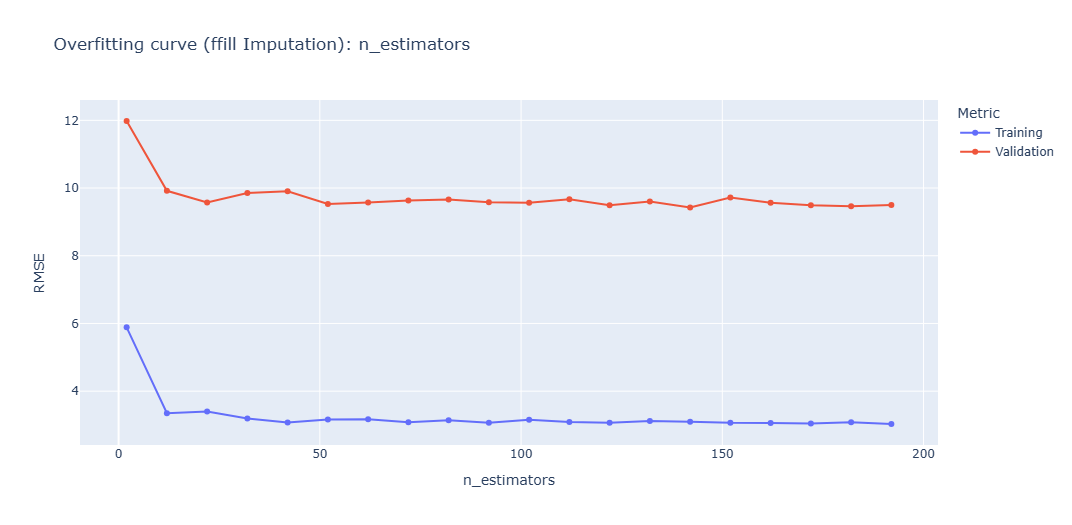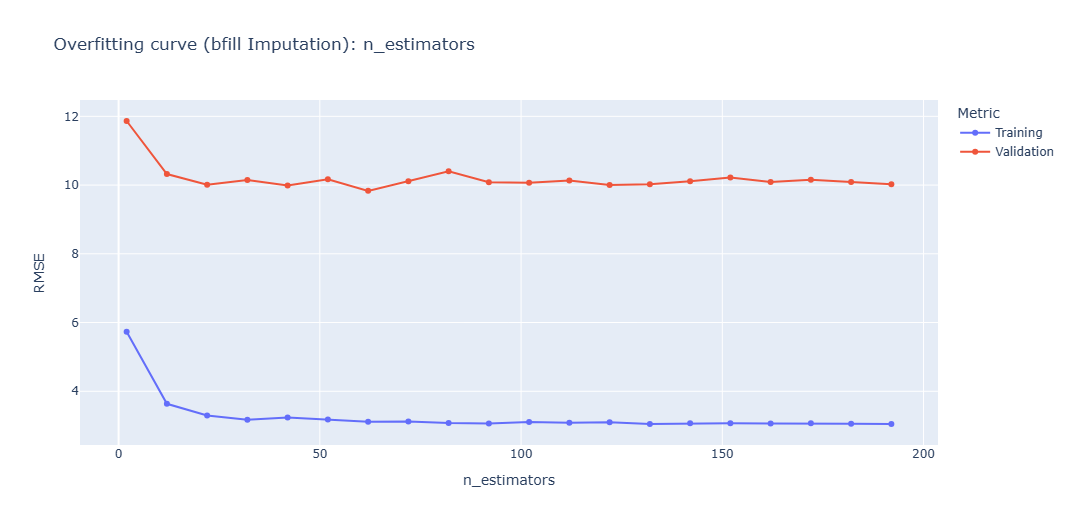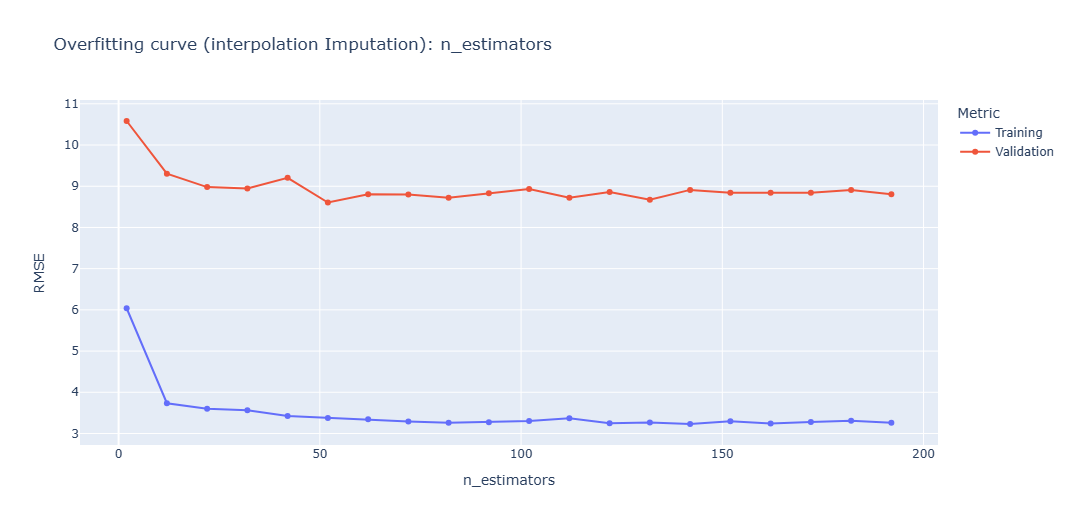

In [ ]:
best_params['n_estimators'] = 52

## max_depth

In [ ]:
test_param_and_plot(
    ModelClass=RandomForestRegressor,
    param_name='max_depth',
    param_values=range(2, 100,2),
    train_inputs=ffill_train_inputs,
    train_target=ffill_train_target,
    val_inputs=ffill_val_inputs,
    val_target=ffill_val_target,
    imputation_method='ffill'
)

test_param_and_plot(
    ModelClass=RandomForestRegressor,
    param_name='max_depth',
    param_values=range(2, 100,2),
    train_inputs=bfill_train_inputs,
    train_target=bfill_train_target,
    val_inputs=bfill_val_inputs,
    val_target=bfill_val_target,
    imputation_method='bfill'
)

test_param_and_plot(
    ModelClass=RandomForestRegressor,
    param_name='max_depth',
    param_values=range(2, 100,2),
    train_inputs=interpolation_train_inputs,
    train_target=interpolation_train_target,
    val_inputs=interpolation_val_inputs,
    val_target=interpolation_val_target,
    imputation_method='interpolation'
)

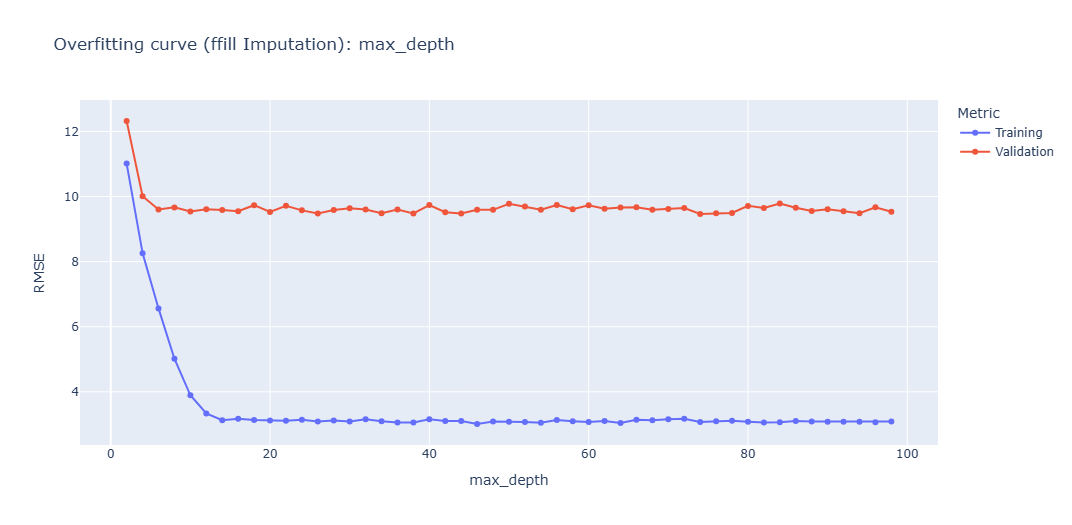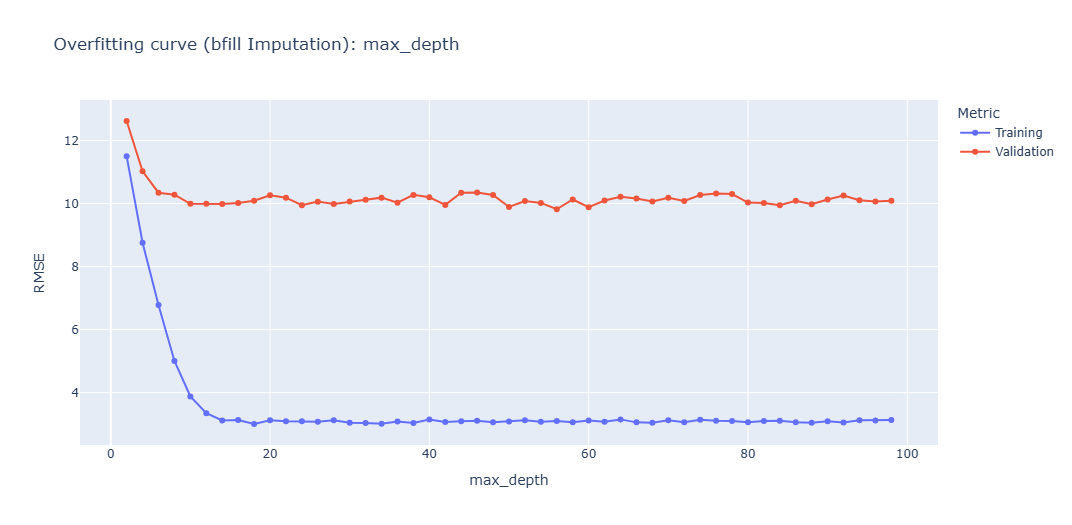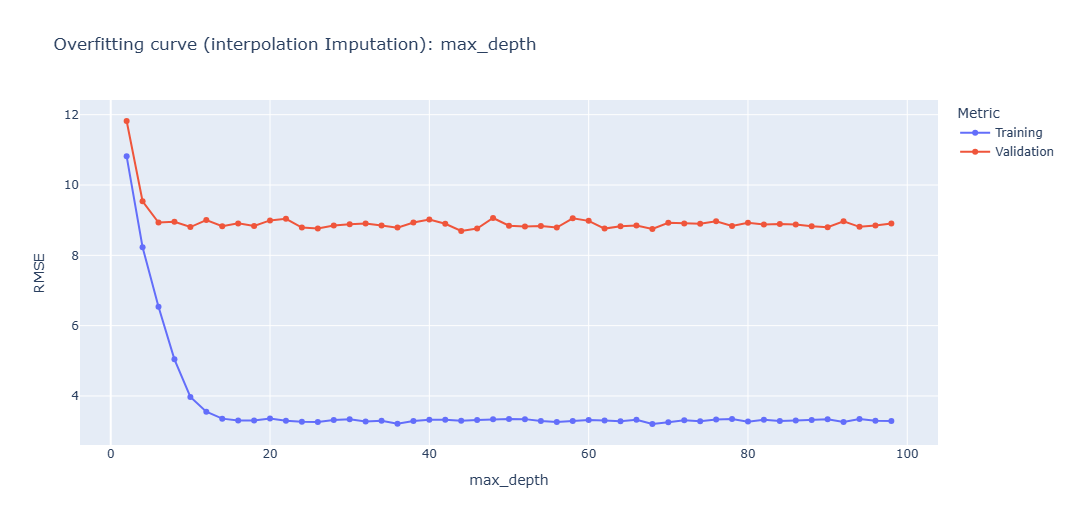

In [ ]:
best_params['max_depth'] = 4

## min_samples_split

In [ ]:
test_param_and_plot(
    ModelClass=RandomForestRegressor,
    param_name='min_samples_split',
    param_values=range(2, 100,2),
    train_inputs=ffill_train_inputs,
    train_target=ffill_train_target,
    val_inputs=ffill_val_inputs,
    val_target=ffill_val_target,
    imputation_method='ffill'
)

test_param_and_plot(
    ModelClass=RandomForestRegressor,
    param_name='min_samples_split',
    param_values=range(2, 100,2),
    train_inputs=bfill_train_inputs,
    train_target=bfill_train_target,
    val_inputs=bfill_val_inputs,
    val_target=bfill_val_target,
    imputation_method='bfill'
)

test_param_and_plot(
    ModelClass=RandomForestRegressor,
    param_name='min_samples_split',
    param_values=range(2, 100,2),
    train_inputs=interpolation_train_inputs,
    train_target=interpolation_train_target,
    val_inputs=interpolation_val_inputs,
    val_target=interpolation_val_target,
    imputation_method='interpolation'
)

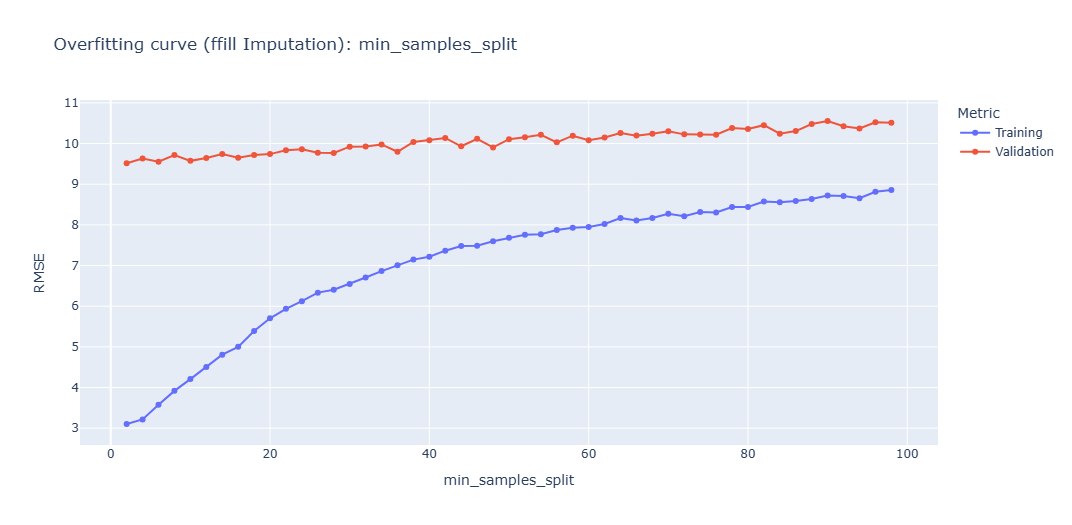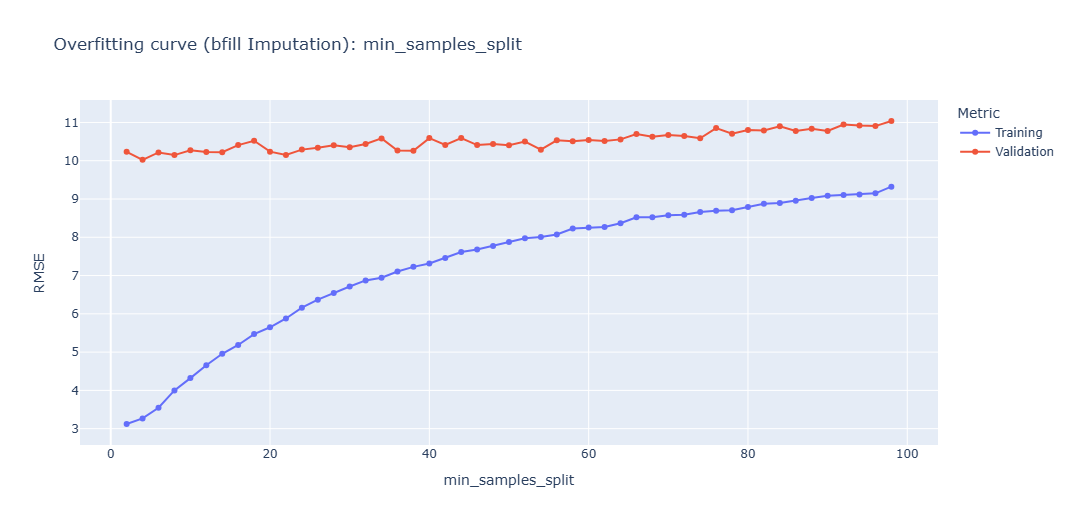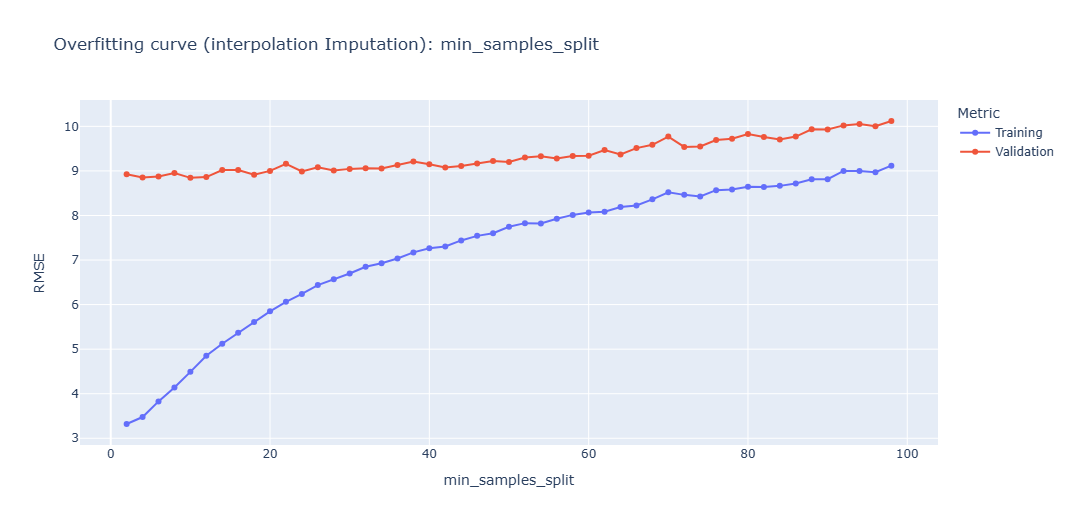

In [ ]:
best_params['min_samples_split'] = 42

## min_samples_leaf

In [ ]:
test_param_and_plot(
    ModelClass=RandomForestRegressor,
    param_name='min_samples_leaf',
    param_values=range(1, 100,2),
    train_inputs=ffill_train_inputs,
    train_target=ffill_train_target,
    val_inputs=ffill_val_inputs,
    val_target=ffill_val_target,
    imputation_method='ffill'
)

test_param_and_plot(
    ModelClass=RandomForestRegressor,
    param_name='min_samples_leaf',
    param_values=range(1, 100,2),
    train_inputs=bfill_train_inputs,
    train_target=bfill_train_target,
    val_inputs=bfill_val_inputs,
    val_target=bfill_val_target,
    imputation_method='bfill'
)

test_param_and_plot(
    ModelClass=RandomForestRegressor,
    param_name='min_samples_leaf',
    param_values=range(1, 100,2),
    train_inputs=interpolation_train_inputs,
    train_target=interpolation_train_target,
    val_inputs=interpolation_val_inputs,
    val_target=interpolation_val_target,
    imputation_method='interpolation'
)

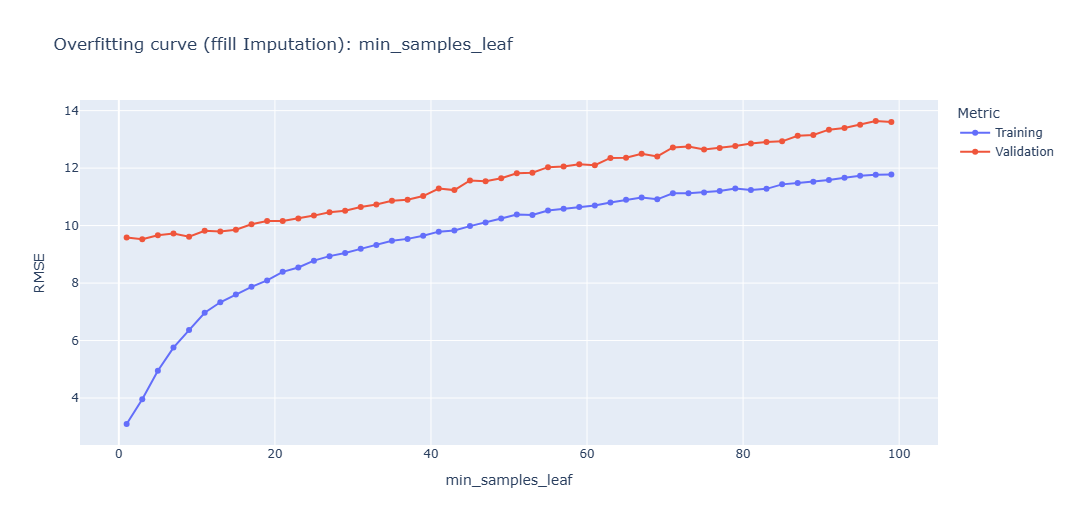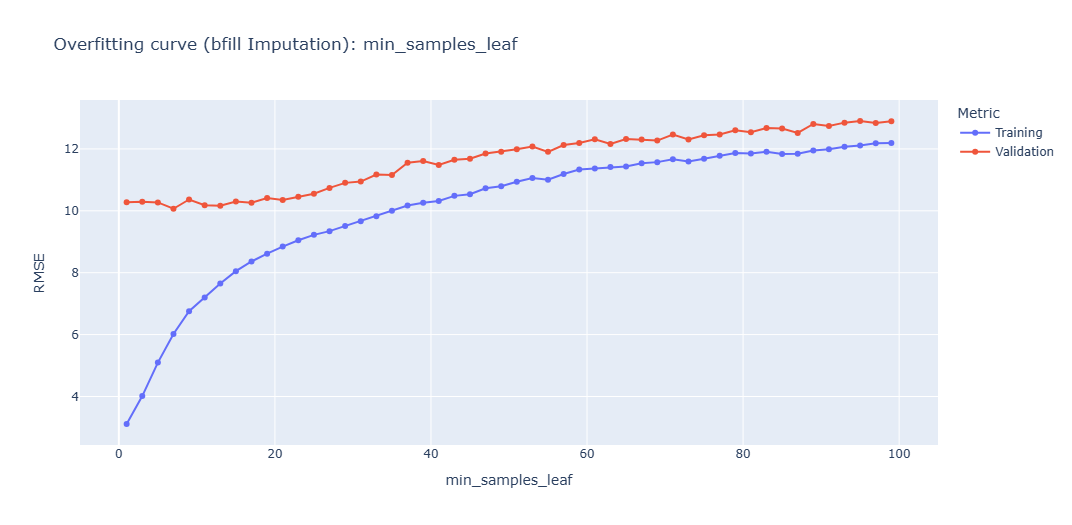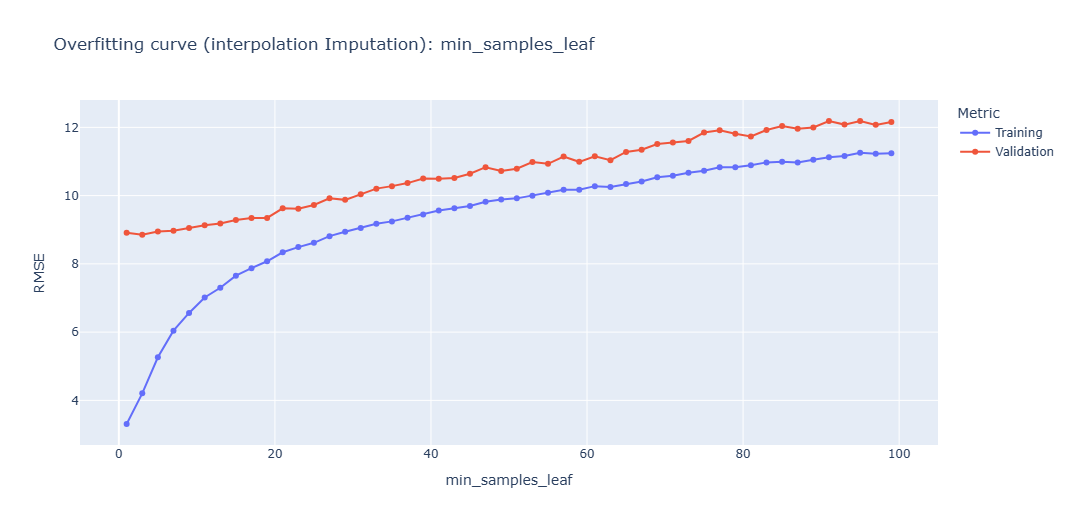

In [ ]:
best_params['min_samples_leaf'] = 19

## min_weight_fraction_leaf

In [ ]:
test_param_and_plot(
    ModelClass=RandomForestRegressor,
    param_name='min_weight_fraction_leaf',
    param_values=np.arange(0,0.5,0.01),
    train_inputs=ffill_train_inputs,
    train_target=ffill_train_target,
    val_inputs=ffill_val_inputs,
    val_target=ffill_val_target,
    imputation_method='ffill'
)

test_param_and_plot(
    ModelClass=RandomForestRegressor,
    param_name='min_weight_fraction_leaf',
    param_values=np.arange(0,0.5,0.01),
    train_inputs=bfill_train_inputs,
    train_target=bfill_train_target,
    val_inputs=bfill_val_inputs,
    val_target=bfill_val_target,
    imputation_method='bfill'
)

test_param_and_plot(
    ModelClass=RandomForestRegressor,
    param_name='min_weight_fraction_leaf',
    param_values=np.arange(0,0.5,0.01),
    train_inputs=interpolation_train_inputs,
    train_target=interpolation_train_target,
    val_inputs=interpolation_val_inputs,
    val_target=interpolation_val_target,
    imputation_method='interpolation'
)

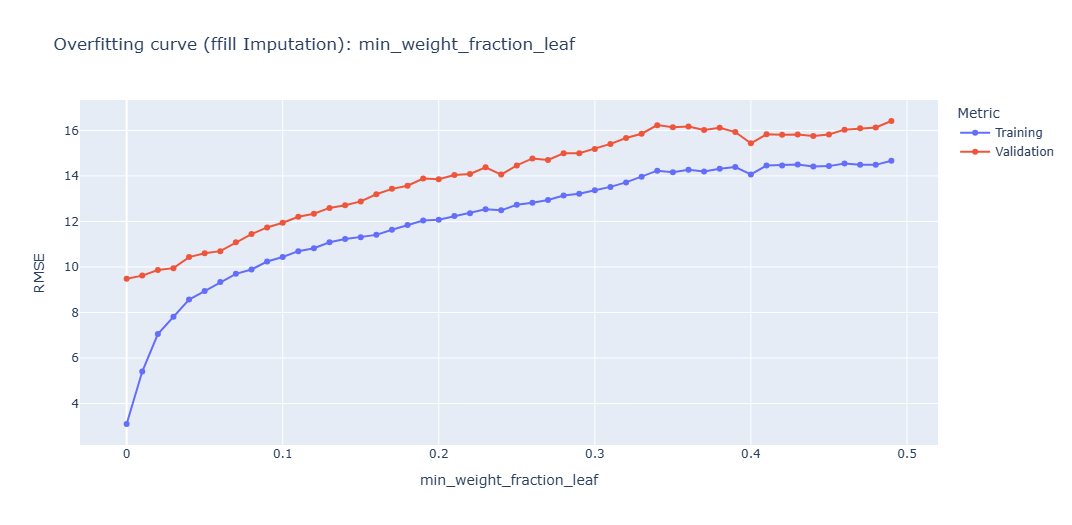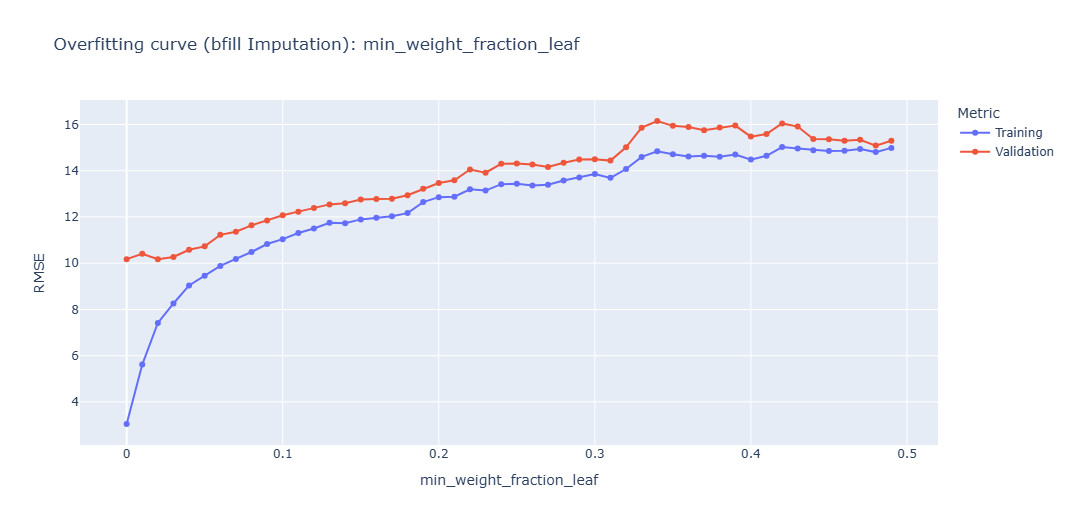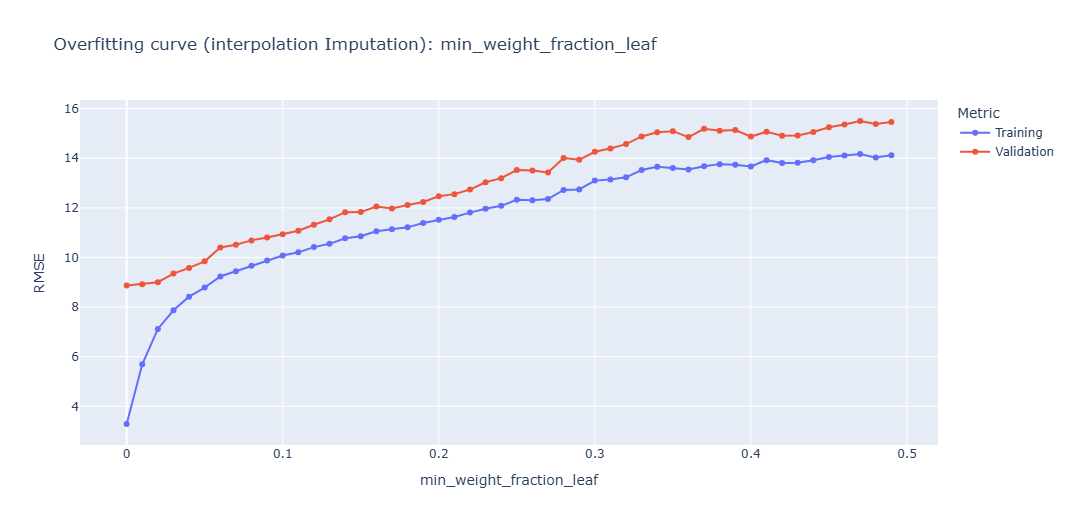

In [ ]:
best_params['min_weight_fraction_leaf'] = 0.04

## max_leaf_nodes

In [ ]:
test_param_and_plot(
    ModelClass=RandomForestRegressor,
    param_name='max_leaf_nodes',
    param_values=range(2, 100,2),
    train_inputs=ffill_train_inputs,
    train_target=ffill_train_target,
    val_inputs=ffill_val_inputs,
    val_target=ffill_val_target,
    imputation_method='ffill'
)

test_param_and_plot(
    ModelClass=RandomForestRegressor,
    param_name='max_leaf_nodes',
    param_values=range(2, 100,2),
    train_inputs=bfill_train_inputs,
    train_target=bfill_train_target,
    val_inputs=bfill_val_inputs,
    val_target=bfill_val_target,
    imputation_method='bfill'
)

test_param_and_plot(
    ModelClass=RandomForestRegressor,
    param_name='max_leaf_nodes',
    param_values=range(2, 100,2),
    train_inputs=interpolation_train_inputs,
    train_target=interpolation_train_target,
    val_inputs=interpolation_val_inputs,
    val_target=interpolation_val_target,
    imputation_method='interpolation'
)

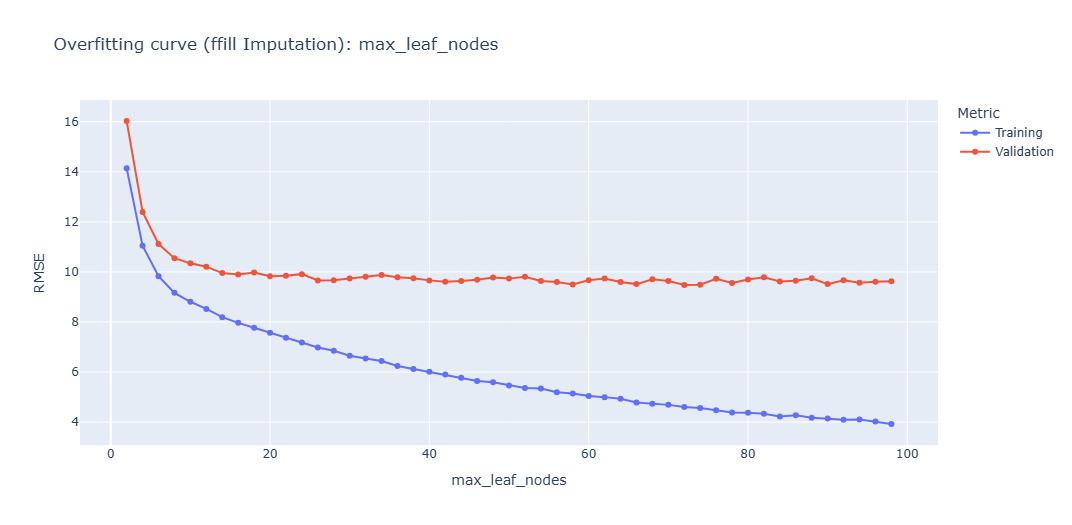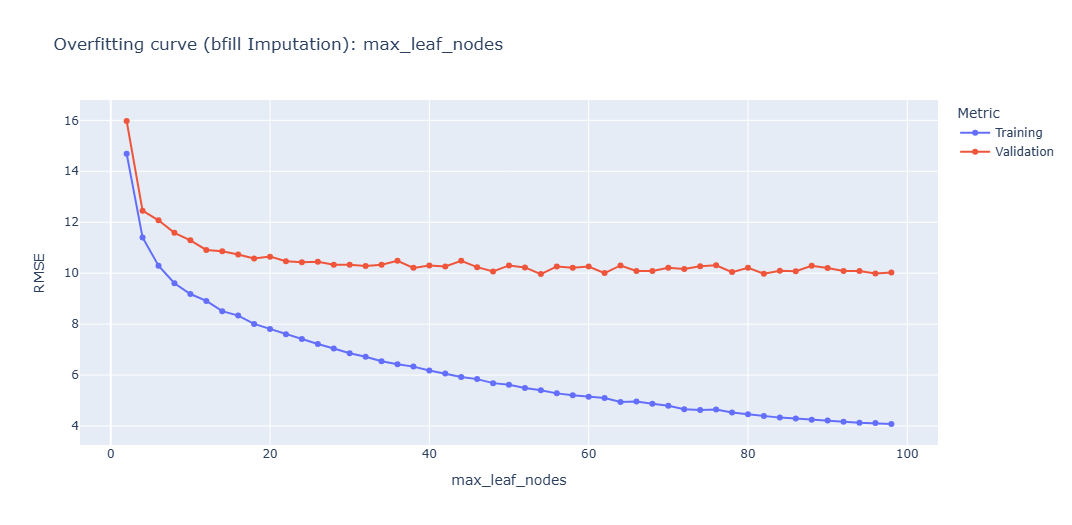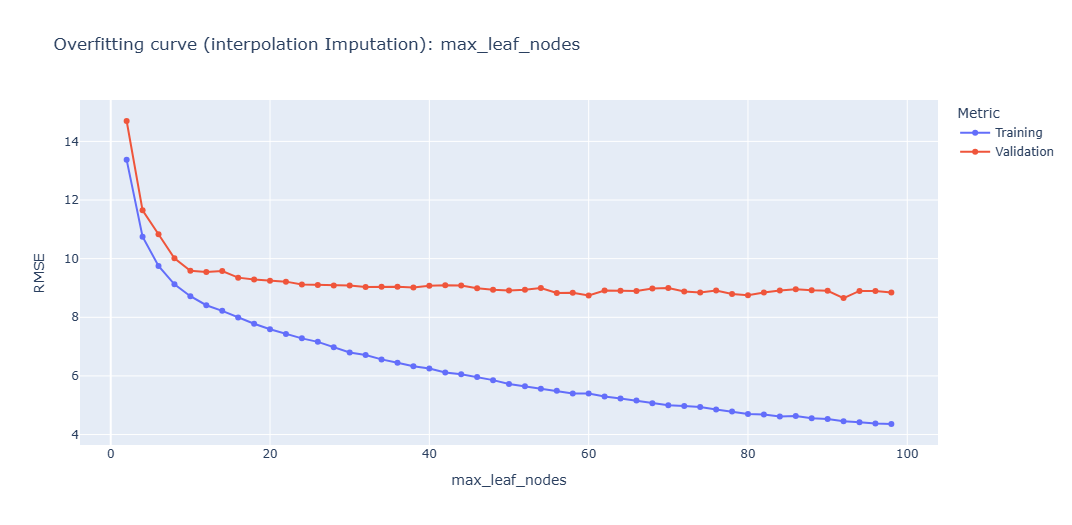

In [ ]:
best_params['max_leaf_nodes'] = 10

In [ ]:
best_params

{'n_estimators': 52,
 'max_depth': 4,
 'min_samples_split': 42,
 'min_samples_leaf': 19,
 'min_weight_fraction_leaf': 0.04,
 'max_leaf_nodes': 10}

- **(n_estimators: 52)** estimator model suffered from extreme overfitting.
- **(max_depth: 4)** limiting individual tree complexity addressed the overfitting issue.
- **(min_samples_split: 42 and min_samples_leaf: 19)** this stabalized the variance; however, implementing this parameter somehow made a gap between the training and validation errors, showing that the model is overfitted.
- **(min_weight_fraction_leaf: 0.04 and max_leaf_nodes: 10)** improved the regularization.

In [ ]:
model_rfr = RandomForestRegressor(**best_params).fit(interpolation_train_inputs, interpolation_train_target)

rfr_prediction_COD = model_rfr.predict(interpolation_val_inputs)

rfr_prediction_COD = pd.Series(rfr_prediction_COD, index=interpolation_val_inputs.index)
rfr_prediction_COD.rename('Random Forest Regressor, Predictions', inplace=True)
rfr_prediction_COD.head(5)

,"Random Forest Regressor, Predictions"
Datetime,
2025-07-16,167.343197
2025-07-17,169.102451
2025-07-18,160.957893
2025-07-19,160.727812
2025-07-20,161.048974


In [ ]:
# Plotting

def model_assessment_plot(train_df, val_df, pred_df, chart_title):

  plt.plot(train_df, label=f'Train Data of ({train_df.name})')
  plt.plot(val_df, label=f'Validation Data of ({val_df.name})')
  plt.plot(pred_df, label=f'Predicted Value')

  plt.xticks(rotation=70)
  plt.xlabel('Date')
  plt.ylabel('COD Values')
  plt.title(f'{chart_title}')
  plt.legend()
  plt.show()

  rmse = root_mean_squared_error(val_df, pred_df)
  mae = mean_absolute_error(val_df, pred_df)
  mape = mean_absolute_percentage_error(val_df, pred_df)

  print(f"{chart_title} RMSE: {rmse}")
  print(f"{chart_title} MAE: {mae}")
  print(f"{chart_title} MAPE: {mape}")

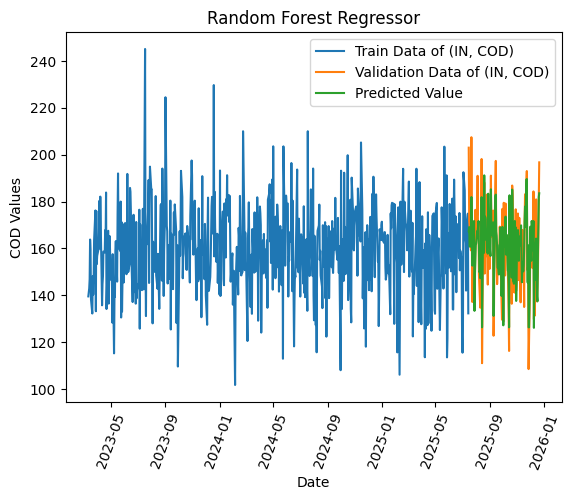

Random Forest Regressor RMSE: 10.014348049066387
Random Forest Regressor MAE: 7.908411709098385
Random Forest Regressor MAPE: 0.050657078910097186


In [ ]:
model_assessment_plot(interpolation_train_target,
                      interpolation_val_target,
                      rfr_prediction_COD,
                      'Random Forest Regressor')

# Residual Analysis and R2 Score

In [ ]:
# Residual Analysis

def residual_analysis(val_df, pred_df):

  residuals = val_df - pred_df

  plt.figure(figsize=(10, 6))
  sns.scatterplot(x=pred_df, y=residuals, alpha=0.6)
  plt.axhline(y=0, color='r', linestyle='--')
  plt.xlabel('Predicted Values')
  plt.ylabel('Residuals')
  plt.title('Residual Plot')
  plt.grid(True)
  plt.tight_layout()
  plt.show()

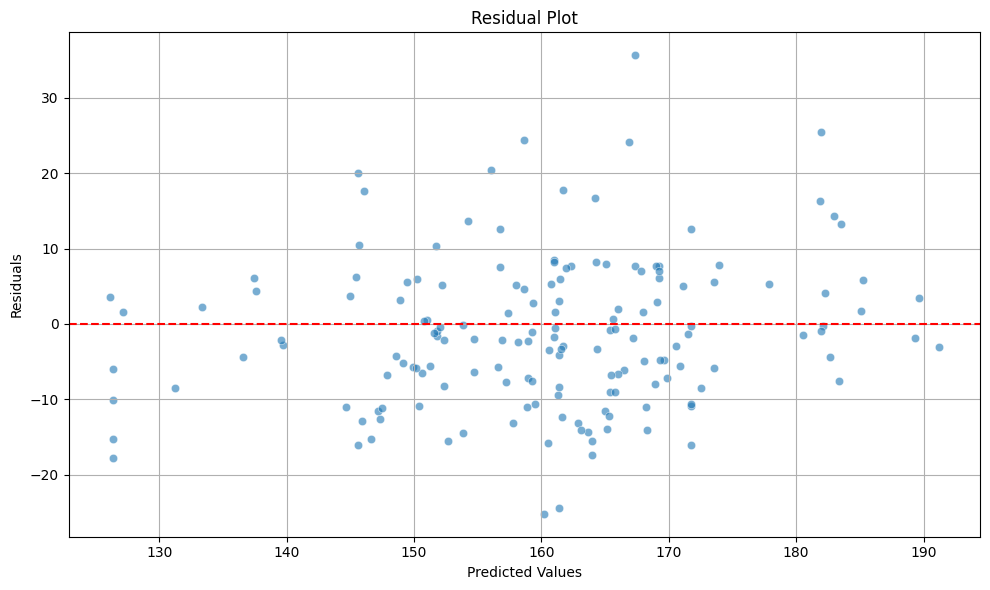

In [ ]:
residual_analysis(interpolation_val_target, rfr_prediction_COD)

Based on the residual plot, some observations exhibit relatively large residuals, suggesting that the model produces larger prediction errors for certain observations

In [ ]:
def r2_score_plot(y_val, y_prediction, model):
    r2 = r2_score(y_val, y_prediction)
    y_val, y_prediction = np.asarray(y_val), np.asarray(y_prediction)

    min_val = min(y_val.min(), y_prediction.min())
    max_val = max(y_val.max(), y_prediction.max())

    plt.figure(figsize=(8, 6))
    plt.scatter(y_val, y_prediction, alpha=0.7, edgecolor='black', label='Predictions')
    plt.plot([min_val, max_val], [min_val, max_val],
             '--', color='red', linewidth=2, label='Perfect Prediction')

    plt.xlabel('Actual COD (mg/L)')
    plt.ylabel('Predicted COD (mg/L)')
    plt.title(f'{model} Model: Actual vs. Predicted COD', fontweight='bold')

    plt.text(
        0.05, 0.95, f'$R^2$ = {r2:.3f}',
        transform=plt.gca().transAxes,
        fontsize=11, fontweight='bold', va='top',
        bbox=dict(boxstyle='round', facecolor='none',
                  edgecolor='black', linewidth=1)
    )

    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

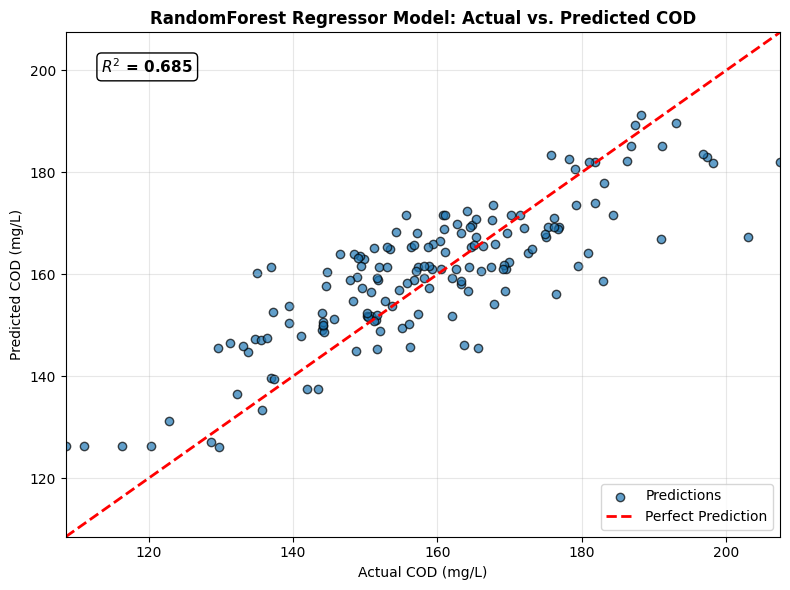

In [ ]:
r2_score_plot(interpolation_val_target,rfr_prediction_COD, 'RandomForest Regressor')

# Feature Importance

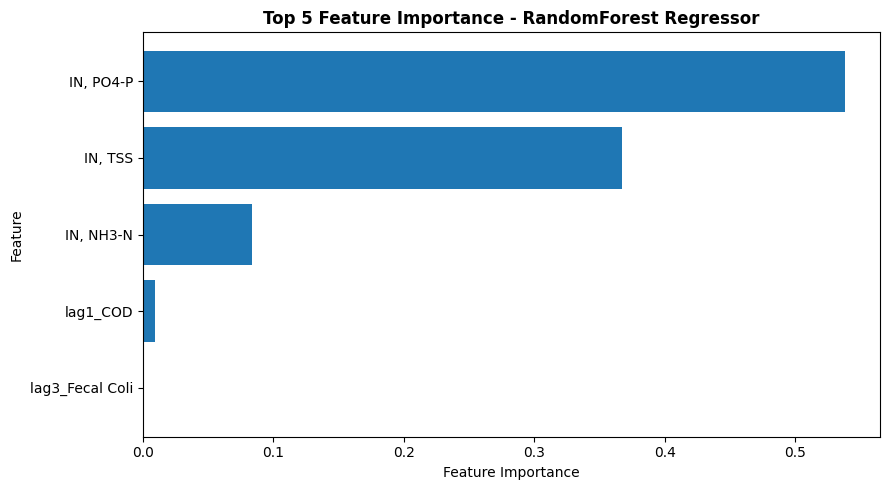

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': interpolation_train_inputs.columns,
    'Importance': model_rfr.feature_importances_
}).sort_values('Importance', ascending=False).head(5)

plt.figure(figsize=(9, 5))

bars = plt.barh(
    feature_importance['Feature'][::-1],
    feature_importance['Importance'][::-1]
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 5 Feature Importance - RandomForest Regressor',
          fontweight='bold')

plt.tight_layout()
plt.show()

- IN, PO4-P is the primary predictor with a dominant importance score of 0.54 and IN, TSS serves as the secondary predictor with a score of roughly 0.37.
- Combined, these two parameters dictate approximately 90% of the model's total predictive weight.



---
# Model Discussion (Random Forest Regressor)

- The interpolation imputation method produced the least error amongst other imputation methods.
- The Random Forest Regressor achieved an **RMSE score of 10.01 and an R2 score of 0.685** which is better than Decision Tree Regressor Model, but worse than Linear Regression and SARIMAX models.


---

